# Laporan Sampel Dataset: Corpus & QA
Notebook ini menampilkan ringkasan dataset `corpus` dan `qa`, contoh baris dengan kolom panjang yang sudah dipotong (truncated), dan beberapa visualisasi sederhana untuk laporan.
- Truncate: kolom panjang seperti `content` atau `generation_gt` dipotong untuk tampilan sampel.
- Jika file parquet tidak ditemukan, notebook mencoba membaca file `.jsonl` alternatif di folder `data/`.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set(style='whitegrid')

# Helper: truncate long text for display
def truncate_text(x, max_chars=300):
    if pd.isna(x):
        return x
    s = str(x)
    if len(s) <= max_chars:
        return s
    # try to avoid cutting mid-word if possible
    t = s[:max_chars].rsplit(' ', 1)[0]
    return t + ' ...'

# Load with fallback: parquet -> jsonl -> empty DataFrame
def load_parquet_or_jsonl(path: Path):
    if path.exists():
        try:
            return pd.read_parquet(path)
        except Exception:
            try:
                return pd.read_json(path, lines=True)
            except Exception as e:
                print(f'Failed reading {path}:', e)
                return pd.DataFrame()
    jsonl = path.with_suffix('.jsonl')
    if jsonl.exists():
        try:
            return pd.read_json(jsonl, lines=True)
        except Exception as e:
            print(f'Failed reading {jsonl}:', e)
            return pd.DataFrame()
    return pd.DataFrame()

base = Path('data')
corpus_path = base / 'corpus.parquet'
qa_path = base / 'qa.parquet'

df_corpus = load_parquet_or_jsonl(corpus_path)
df_qa = load_parquet_or_jsonl(qa_path)

print('Loaded Corpus rows:', len(df_corpus))
print('Loaded QA rows:', len(df_qa))

Loaded Corpus rows: 2469
Loaded QA rows: 600


## Ringkasan Corpus

In [2]:
# Corpus quick summary + truncated sample display
if df_corpus.empty:
    print('Tidak ada data corpus terdeteksi (cek data/corpus.parquet atau data/corpus.jsonl).')
else:
    print('Kolom corpus:', df_corpus.columns.tolist())
    display(df_corpus.head(3))
    # compute content length if a content-like column exists
    content_col = None
    for candidate in ['content', 'contents', 'text', 'body']:
        if candidate in df_corpus.columns:
            content_col = candidate
            break
    if content_col is not None:
        df_corpus['_content_len'] = df_corpus[content_col].astype(str).apply(len)
        display(df_corpus['_content_len'].describe().to_frame().T)
        # show truncated sample column side-by-side
        sample = df_corpus.copy()
        sample['content_trunc'] = sample[content_col].apply(lambda s: truncate_text(s, max_chars=300))
        display(sample[[content_col, 'content_trunc']].head(10))
    else:
        print('Tidak menemukan kolom konten yang umum (content/contents/text/body).')

Kolom corpus: ['doc_id', 'contents', 'metadata']


,doc_id,contents,metadata
0,dc9b290175ed088f3ca2693e3dbe6657,Cultivation and propagation of Alfalfa (Part 1...,"{'category': None, 'chunk': 0, 'disease': None..."
1,86e3f1bdfc14b608cf542abfc4c71dd6,Cultivation and propagation of Alfalfa (Part 2...,"{'category': None, 'chunk': 1, 'disease': None..."
2,4ac60b94f1274d11049d9c1890f68841,Cultivation and propagation of Alfalfa (Part 3...,"{'category': None, 'chunk': 2, 'disease': None..."


,count,mean,std,min,25%,50%,75%,max
_content_len,2469.0,687.420818,532.560956,74.0,376.0,556.0,807.0,6972.0


,contents,content_trunc
0,Cultivation and propagation of Alfalfa (Part 1...,Cultivation and propagation of Alfalfa (Part 1...
1,Cultivation and propagation of Alfalfa (Part 2...,Cultivation and propagation of Alfalfa (Part 2...
2,Cultivation and propagation of Alfalfa (Part 3...,Cultivation and propagation of Alfalfa (Part 3...
3,Disease: Alfalfa Mosaic affecting Alfalfa\n\nS...,Disease: Alfalfa Mosaic affecting Alfalfa\n\nS...
4,Disease: Anthracnose affecting Alfalfa\n\nSymp...,Disease: Anthracnose affecting Alfalfa\n\nSymp...
5,Disease: Common Leaf Spot affecting Alfalfa\n\...,Disease: Common Leaf Spot affecting Alfalfa\n\...
6,Disease: Downy Mildew affecting Alfalfa\n\nSym...,Disease: Downy Mildew affecting Alfalfa\n\nSym...
7,Disease: Fusarium Wilt affecting Alfalfa\n\nSy...,Disease: Fusarium Wilt affecting Alfalfa\n\nSy...
8,Disease: Lepto Leaf Spot affecting Alfalfa\n\n...,Disease: Lepto Leaf Spot affecting Alfalfa\n\n...
9,Disease: Aphanomyces Root Rot affecting Alfalf...,Disease: Aphanomyces Root Rot affecting Alfalf...


## Ringkasan QA

In [3]:
# QA quick summary + truncated sample display
if df_qa.empty:
    print('Tidak ada data QA terdeteksi (cek data/qa.parquet atau data/qa.jsonl).')
else:
    print('Kolom QA:', df_qa.columns.tolist())
    display(df_qa.head(3))
    # common QA text fields to truncate for sample view
    qa_text_candidates = ['generation_gt', 'answer', 'context', 'question', 'generation']
    found = [c for c in qa_text_candidates if c in df_qa.columns]
    if found:
        col = found[0]
        df_qa['_qa_len'] = df_qa[col].astype(str).apply(len)
        display(df_qa['_qa_len'].describe().to_frame().T)
        sample = df_qa.copy()
        sample[col + '_trunc'] = sample[col].apply(lambda s: truncate_text(s, max_chars=300))
        display(sample[[col, col + '_trunc']].head(10))
    else:
        print('Tidak menemukan kolom QA teks yang umum (generation_gt/answer/context/question).')

Kolom QA: ['qid', 'query', 'retrieval_gt', 'generation_gt']


,qid,query,retrieval_gt,generation_gt
0,da25227f-1b4e-4907-81e2-a3b3fef62300,What are the basic requirements for Alfalfa to...,[[dc9b290175ed088f3ca2693e3dbe6657]],"[Alfalfa grows best in deep, fertile, well-dra..."
1,bb8ccee4-864e-44f4-9ea6-598836b4a546,What guideline dictates that you can plant alf...,[[86e3f1bdfc14b608cf542abfc4c71dd6]],[The guideline dictates that you can plant alf...
2,ef6bcdcb-ccd6-430b-9471-8c00c3debf41,What are the various considerations for harves...,[[4ac60b94f1274d11049d9c1890f68841]],[Alfalfa is harvested at different times depen...


,count,mean,std,min,25%,50%,75%,max
_qa_len,600.0,767.655,768.745701,58.0,179.25,405.0,1132.75,3662.0


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## Visualisasi: Distribusi Panjang Dokumen / Jawaban

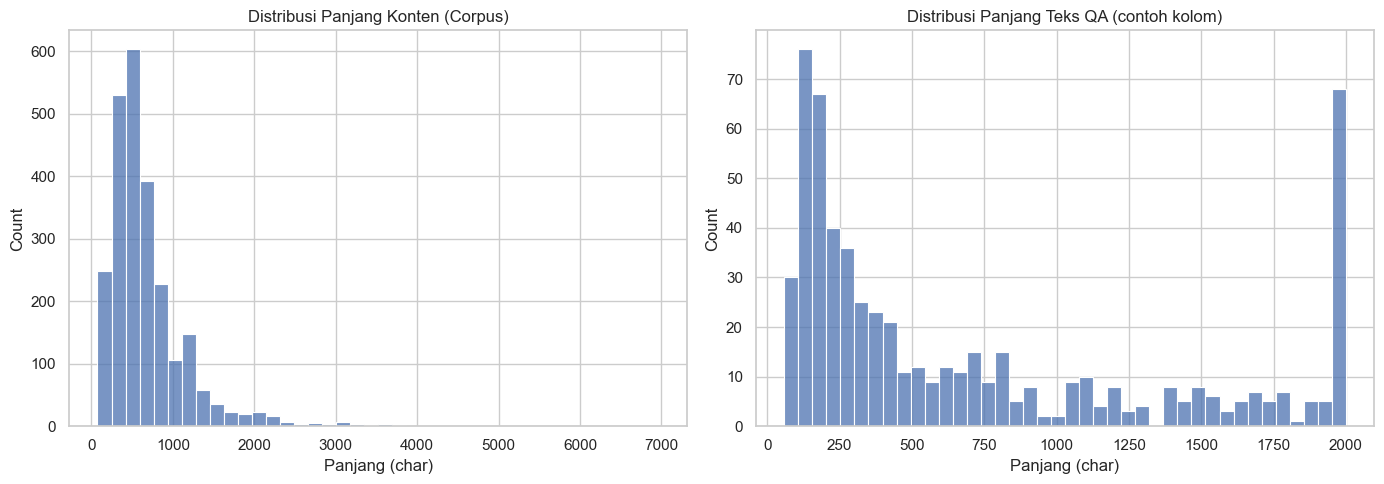

In [4]:
# Plot document length distribution for corpus and QA (if available)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Corpus length histogram
if (not df_corpus.empty) and ('_content_len' in df_corpus.columns):
    sns.histplot(df_corpus['_content_len'].clip(upper=50000), bins=40, ax=axes[0])
    axes[0].set_title('Distribusi Panjang Konten (Corpus)')
    axes[0].set_xlabel('Panjang (char)')
else:
    axes[0].text(0.5, 0.5, 'No corpus length data', ha='center')
    axes[0].set_axis_off()

# QA length histogram
qa_len_col = '_qa_len'
if (not df_qa.empty) and (qa_len_col in df_qa.columns):
    sns.histplot(df_qa[qa_len_col].clip(upper=2000), bins=40, ax=axes[1])
    axes[1].set_title('Distribusi Panjang Teks QA (contoh kolom)')
    axes[1].set_xlabel('Panjang (char)')
else:
    axes[1].text(0.5, 0.5, 'No QA length data', ha='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

---
Catatan: jika Anda ingin contoh lebih banyak atau kolom-kolom tertentu ditampilkan, beritahu saya kolom mana yang ingin difokuskan, dan saya akan tambahkan filter dan tampilan lanjut.